In [1]:
import pandas as pd
import glob
import os

# 1. 自动查找数据文件路径
input_path = '/kaggle/input/datasets/henriqueyamahata/bank-marketing'
files = glob.glob(os.path.join(input_path, '*.csv'))
print("📂 找到的文件有:", files)

# 2. 读取数据：尝试默认逗号，如果只有1列，自动切换为分号
df = pd.read_csv(files[0], sep=';')

print("\n🏷️ 当前数据集的所有列名:")
print(df.columns.tolist())

# 3. 目标变量适配 (如果列名不叫 'y'，可能是 'deposit')
target_col = 'y'
if 'y' not in df.columns:
    if 'deposit' in df.columns:
        target_col = 'deposit'
        print(f"\n💡 发现目标变量名被改为了 '{target_col}'，已自动适配。")
    else:
        print("\n❌ 错误：未找到目标变量！请检查上面打印的列名。")

# 4. 继续你原本的探索分析
print(f"\n📊 数据规模: {df.shape}")
print(f"\n🎯 目标变量 ({target_col}) 分布:")
print(df[target_col].value_counts(normalize=True).map('{:.1%}'.format))

print("\n✅ 缺失值检查:")
missing_count = df.isnull().sum().sum()
print(f"{missing_count} 个缺失值" if missing_count > 0 else "✅ 无缺失值")

print("\n👀 前5行预览:")
display(df.head())

📂 找到的文件有: ['/kaggle/input/datasets/henriqueyamahata/bank-marketing/bank-additional-full.csv']

🏷️ 当前数据集的所有列名:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

📊 数据规模: (41188, 21)

🎯 目标变量 (y) 分布:
y
no     88.7%
yes    11.3%
Name: proportion, dtype: object

✅ 缺失值检查:
✅ 无缺失值

👀 前5行预览:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 设置图像保存目录
SAVE_DIR = '/kaggle/working/figures'
os.makedirs(SAVE_DIR, exist_ok=True)

# 设置matplotlib参数
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

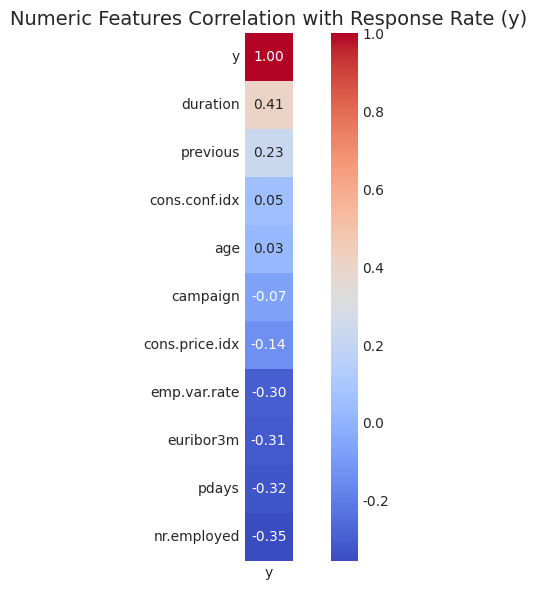

✅ 相关性热力图已保存至: /kaggle/working/figures/correlation_heatmap.png


<Figure size 640x480 with 0 Axes>

In [3]:
# 导入数据分析所需的核心库
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
import warnings  
warnings.filterwarnings('ignore')  

# 使用系统自带字体解决中文显示问题
plt.rcParams['font.sans-serif'] = ['DejaVu Sans'] # 如果在Kaggle乱码，可以把标题换成英文
plt.rcParams['axes.unicode_minus'] = False  

# 1. 读取数据 (🚨关键修复：添加 sep=';' 处理完整版数据的分隔符)
file_path = '/kaggle/input/datasets/henriqueyamahata/bank-marketing/bank-additional-full.csv'
df = pd.read_csv(file_path, sep=';')  

# 2. 快速查看数值特征与目标变量关系
# 🚨关键修复：根据完整版数据集的实际情况，更新数值型列 (移除了不存在的 balance 和 day，加入了宏观经济指标)
num_cols = [
    'age', 'duration', 'campaign', 'pdays', 'previous', 
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'
]

# 创建包含数值特征和目标变量的副本数据帧
corr_matrix = df[num_cols + ['y']].copy()

# 将目标变量 `y` 从字符串（'yes'/'no'）编码为0/1
corr_matrix['y'] = (corr_matrix['y'] == 'yes').astype(int)

# 3. 创建热力图以直观展示相关性
plt.figure(figsize=(8, 6)) # 稍微调大一点画布，因为变量变多了
sns.heatmap(
    corr_matrix.corr(numeric_only=True)[['y']].sort_values('y', ascending=False), 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    square=True
)
plt.title('Numeric Features Correlation with Response Rate (y)', fontsize=14) 
plt.tight_layout() 
plt.show()

# 保存图像
corr_file = os.path.join(SAVE_DIR, 'correlation_heatmap.png')
plt.savefig(corr_file, dpi=150, bbox_inches='tight')
print(f"✅ 相关性热力图已保存至: {corr_file}")
plt.show()


In [4]:
import pandas as pd
import numpy as np

# 复制数据，保护原表
df_model = df.copy()

# 1. 剔除事后特征 & 强共线性宏观经济指标
drop_cols = ['duration', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
df_model.drop(columns=drop_cols, inplace=True, errors='ignore')

# 2. 🚨 关键修复：完整版数据用 999 表示未联系
df_model['has_prev_contact'] = (df_model['pdays'] != 999).astype(int)
df_model['pdays_clean'] = df_model['pdays'].where(df_model['pdays'] != 999, 0)
df_model.drop(columns=['pdays'], inplace=True, errors='ignore') # 彻底剔除原始 pdays

# 3. 目标变量编码
df_model['target'] = (df_model['y'] == 'yes').astype(int)

# 4. 🚨 关键修复：将 day_of_week 加入哑变量编码列表
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
            'contact', 'month', 'day_of_week', 'poutcome']

df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# 移除原始的文本 'y' 列
df_encoded.drop(columns=['y'], inplace=True, errors='ignore')

# 规避结构性共线性：在完整版中，'未知结果'通常叫 'poutcome_nonexistent'，我们将其剔除作为基准类
if 'poutcome_nonexistent' in df_encoded.columns:
    df_encoded.drop(columns=['poutcome_nonexistent'], inplace=True)

# 5. 准备最终的 X 和 y (确保所有列都是数值型，bool 转 int)
X = df_encoded.drop(columns=['target']).astype(float)
y = df_encoded['target']

print(f"🔥 4.5万条全量特征矩阵准备完毕！当前维度: {X.shape}")
# 把处理好的全量数据保存到工作区
df_encoded.to_csv('/kaggle/working/bank_cleaned_features.csv', index=False)

🔥 4.5万条全量特征矩阵准备完毕！当前维度: (41188, 47)


In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, classification_report


# 应该先进行训练测试分割
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. 剔除导致完全共线性的列
cols_to_drop = [
    'pdays', 
    'poutcome_unknown', 
    'poutcome_nonexistent', 
    'loan_unknown', # 解决与 housing_unknown 的完美共线性
    'default_yes'   # 解决样本极度稀疏导致的梯度消失
]

for col in cols_to_drop:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
        X_test = X_test.drop(columns=[col], errors='ignore')

# 🚨 新增防护：自动找出并剔除训练集中全为 0 或 1 的常数列 (如极稀疏的 default_yes)
zero_var_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]
if zero_var_cols:
    print(f"⚠️ 拦截到方差为0的常数列（极可能导致奇异矩阵报错），正在自动剔除: {zero_var_cols}")
    X_train = X_train.drop(columns=zero_var_cols)
    # 测试集也要同步剔除，保证维度一致
    X_test = X_test.drop(columns=zero_var_cols, errors='ignore') 

# ========== 关键修复：转换 bool 为 int ==========
X_train = X_train.astype(int)
X_test = X_test.astype(int)

# 为特征矩阵添加常数项（截距项）
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# 2. 拟合 Logistic 回归模型
# 如果牛顿法 (newton) 偶发不收敛，可以使用 method='bfgs' 作为最稳健的备选方案
print("\n🚀 正在拟合 Logistic 回归模型...")
logit_model = sm.Logit(y_train, X_train_sm).fit(method='bfgs', maxiter=150, disp=0)
print(logit_model.summary())

# 3. 预测与评估
y_pred_prob = logit_model.predict(X_test_sm)
# 暂时保持 0.5 阈值
y_pred = (y_pred_prob >= 0.5).astype(int) 

print("\n=== 测试集评估 ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_prob):.3f}")
print(classification_report(y_test, y_pred, target_names=['未响应', '已响应']))


🚀 正在拟合 Logistic 回归模型...
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                32950
Model:                          Logit   Df Residuals:                    32904
Method:                           MLE   Df Model:                           45
Date:                Wed, 13 May 2026   Pseudo R-squ.:                  0.1723
Time:                        13:46:51   Log-Likelihood:                -9588.7
converged:                      False   LL-Null:                       -11585.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            -1.5733      0.171     -9.204      0.000      -1.908      -1.238
age                               0.0047      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# 1. 获取测试集的预测概率（正类的概率）
# 注意：logit_model.predict 默认输出的就是属于正类(1)的概率
y_pred_prob = logit_model.predict(X_test_sm)

# 2. 计算 ROC 曲线参数
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_prob)

# 3. 计算约登指数 (J = TPR - FPR)，找到最佳阈值
J = tpr - fpr
best_idx = np.argmax(J)
best_threshold = thresholds_roc[best_idx]

print(f"📊 基于约登指数的最佳分类阈值: {best_threshold:.4f}\n")

# 4. 用新阈值重新生成预测标签
y_pred_optimal = (y_pred_prob >= best_threshold).astype(int)

# 5. 重新输出评估报告
print("=== 调整阈值后的测试集评估 ===")
print(classification_report(y_test, y_pred_optimal, target_names=['未响应', '已响应']))

📊 基于约登指数的最佳分类阈值: 0.1356

=== 调整阈值后的测试集评估 ===
              precision    recall  f1-score   support

         未响应       0.93      0.88      0.91      7303
         已响应       0.36      0.52      0.42       935

    accuracy                           0.84      8238
   macro avg       0.65      0.70      0.66      8238
weighted avg       0.87      0.84      0.85      8238



推荐的正负样本权重比 (scale_pos_weight): 7.89

=== LightGBM 测试集评估 (默认 0.5 阈值 + 样本权重平衡) ===
AUC-ROC: 0.761
              precision    recall  f1-score   support

         未响应       0.94      0.85      0.89      7303
         已响应       0.33      0.55      0.41       935

    accuracy                           0.82      8238
   macro avg       0.63      0.70      0.65      8238
weighted avg       0.87      0.82      0.84      8238



<Figure size 1000x800 with 0 Axes>

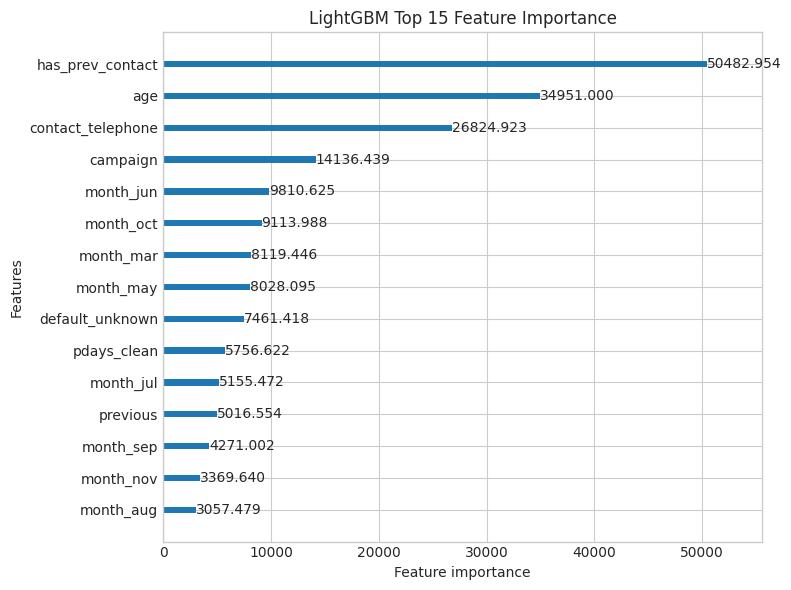

✅ 特征重要性图已保存至: /kaggle/working/figures/feature_importance.png


<Figure size 640x480 with 0 Axes>

In [7]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

# 1. 计算正负样本比例，用于 LightGBM 自动平衡权重
# scale_pos_weight = 负样本数量 / 正样本数量
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"推荐的正负样本权重比 (scale_pos_weight): {ratio:.2f}")

# 2. 配置 LightGBM 参数
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'scale_pos_weight': ratio, # 核心参数：自动处理正负样本不平衡
    'random_state': 42,
    'verbose': -1
}

# 3. 训练模型
clf_lgb = lgb.LGBMClassifier(**params, n_estimators=200)
# 注意：如果是之前 statsmodels 加过常数项的 X_train_sm，最好换回原始的 X_train
clf_lgb.fit(X_train, y_train)

# 4. 预测与评估 (LightGBM 输出了概率后，我们依然可以用你之前找到的最佳阈值 0.1414)
y_pred_prob_lgb = clf_lgb.predict_proba(X_test)[:, 1]

# 我们先看看默认 0.5 阈值在加了权重的 LGBM 表现如何
y_pred_lgb_default = (y_pred_prob_lgb >= 0.5).astype(int)

print("\n=== LightGBM 测试集评估 (默认 0.5 阈值 + 样本权重平衡) ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_prob_lgb):.3f}")
print(classification_report(y_test, y_pred_lgb_default, target_names=['未响应', '已响应']))

# 5. 可视化特征重要性 (Feature Importance)
plt.figure(figsize=(10, 8))
lgb.plot_importance(clf_lgb, max_num_features=15, importance_type='gain', 
                    title='LightGBM Top 15 Feature Importance', figsize=(8, 6))
plt.tight_layout()
plt.show()

importance_file = os.path.join(SAVE_DIR, 'feature_importance.png')
plt.savefig(importance_file, dpi=150, bbox_inches='tight')
print(f"✅ 特征重要性图已保存至: {importance_file}")
plt.show()

In [8]:
import numpy as np
from sklearn.metrics import roc_curve, classification_report

# 1. 计算 ROC 曲线参数 (注意这里使用的是 LightGBM 的预测概率 y_pred_prob_lgb)
fpr_lgb, tpr_lgb, thresholds_lgb = roc_curve(y_test, y_pred_prob_lgb)

# 2. 计算约登指数 (J = TPR - FPR) 寻找最佳阈值
J_lgb = tpr_lgb - fpr_lgb
best_idx_lgb = np.argmax(J_lgb)
best_threshold_lgb = thresholds_lgb[best_idx_lgb]

print(f"🌟 基于约登指数的 LightGBM 最佳分类阈值: {best_threshold_lgb:.4f}\n")

# 3. 使用新阈值重新生成预测结果
y_pred_optimal_lgb = (y_pred_prob_lgb >= best_threshold_lgb).astype(int)

# 4. 输出调整阈值后的最终评估报告
print("=== LightGBM 调整阈值后的测试集评估 ===")
print(classification_report(y_test, y_pred_optimal_lgb, target_names=['未响应', '已响应']))

🌟 基于约登指数的 LightGBM 最佳分类阈值: 0.4858

=== LightGBM 调整阈值后的测试集评估 ===
              precision    recall  f1-score   support

         未响应       0.94      0.83      0.88      7303
         已响应       0.31      0.59      0.40       935

    accuracy                           0.80      8238
   macro avg       0.62      0.71      0.64      8238
weighted avg       0.87      0.80      0.83      8238



🔄 正在计算SHAP值...
✅ SHAP蜂群图已保存至: /kaggle/working/figures/shap_beeswarm.png


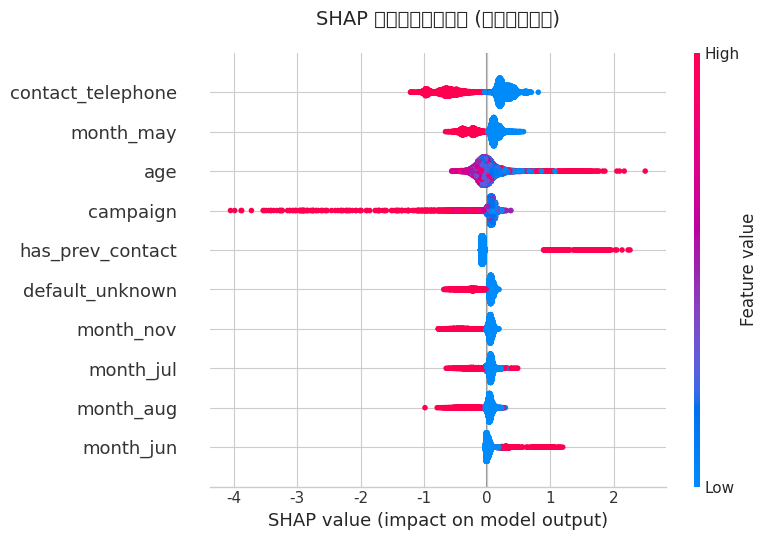

✅ SHAP年龄依赖图已保存至: /kaggle/working/figures/shap_age_dependence.png


<Figure size 800x500 with 0 Axes>

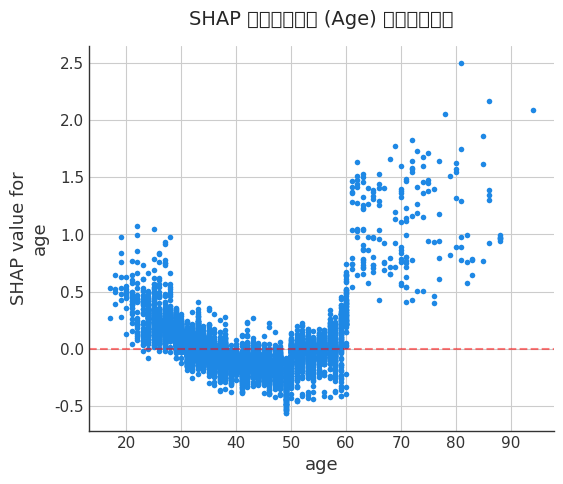

✅ SHAP pdays依赖图已保存至: /kaggle/working/figures/shap_pdays_dependence.png


<Figure size 800x500 with 0 Axes>

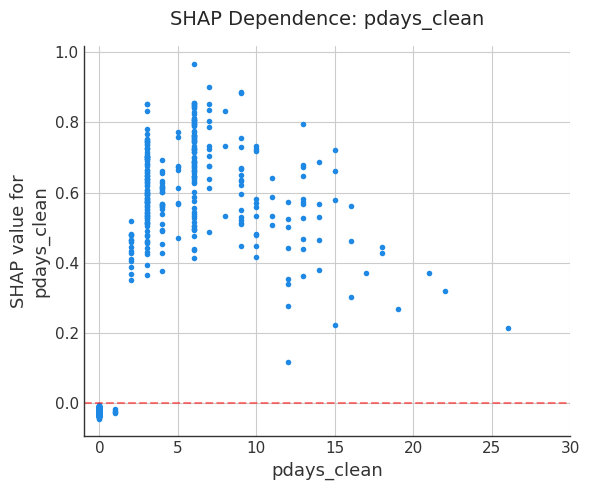

In [9]:
import shap

# 首先计算SHAP值
print("🔄 正在计算SHAP值...")
explainer = shap.TreeExplainer(clf_lgb)
shap_values = explainer.shap_values(X_test)

# 确保使用正类的SHAP值
shap_values_pos = shap_values[1] if isinstance(shap_values, list) else shap_values

# 2. 绘制全局蜂群图
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_pos, X_test, max_display=10, show=False)
plt.title("SHAP 全局特征影响分布 (完整版数据集)", fontsize=14, pad=20)
plt.tight_layout()

# 保存蜂群图
beeswarm_file = os.path.join(SAVE_DIR, 'shap_beeswarm.png')
plt.savefig(beeswarm_file, dpi=150, bbox_inches='tight')
print(f"✅ SHAP蜂群图已保存至: {beeswarm_file}")
plt.show()

# 3. 修改：探究年龄 (age) 的非线性影响
plt.figure(figsize=(8, 5))
shap.dependence_plot('age', shap_values_pos, X_test, interaction_index=None, show=False)
plt.title("SHAP 依赖图：年龄 (Age) 的非线性影响", fontsize=14, pad=15)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)

# 保存年龄依赖图
age_dep_file = os.path.join(SAVE_DIR, 'shap_age_dependence.png')
plt.savefig(age_dep_file, dpi=150, bbox_inches='tight')
print(f"✅ SHAP年龄依赖图已保存至: {age_dep_file}")
plt.show()

# 4. 探究 pdays_clean 的非线性影响
target_feature = 'pdays_clean'
if target_feature in X_test.columns:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(target_feature, shap_values_pos, X_test, interaction_index=None, show=False)
    plt.title(f"SHAP Dependence: {target_feature}", fontsize=14, pad=15)
    plt.axhline(0, color='red', linestyle='--', alpha=0.5)
    plt.xlim(-1, 30) 
    plt.tight_layout()
    
    # 保存pdays依赖图
    pdays_dep_file = os.path.join(SAVE_DIR, 'shap_pdays_dependence.png')
    plt.savefig(pdays_dep_file, dpi=150, bbox_inches='tight')
    print(f"✅ SHAP pdays依赖图已保存至: {pdays_dep_file}")
    plt.show()

In [10]:
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, roc_curve

# 1. 准备全量数据 (直接使用我们最初做完特征工程的 X 和 y)
# 确保 X 里面没有 target 列
print(f"全量特征矩阵维度: {X.shape}")

# 2. 设置 5 折交叉验证
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# 初始化一个全零数组，用于存储全量数据的 OOF (Out-Of-Fold) 预测概率
oof_preds = np.zeros(len(X))

# 获取目标变量的正负样本比例，用于 LightGBM 自动加权
ratio = float(np.sum(y == 0)) / np.sum(y == 1)

# 3. 设定 LightGBM 参数 (增加对泛化能力的控制)
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,  # 稍微调低学习率，让模型学得更细致
    'num_leaves': 31,
    'max_depth': 6,         # 限制树深度，防止过拟合
    'scale_pos_weight': ratio,
    'subsample': 0.8,       # 每次训练随机抽取 80% 样本
    'colsample_bytree': 0.8,# 每次训练随机抽取 80% 特征
    'random_state': 42,
    'verbose': -1
}

print(f"🔥 开始 {n_splits} 折交叉验证训练...\n")

# 4. 开始 CV 循环
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    # 划分当前折的训练集和验证集
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]
    
    # 转换为 LightGBM 专用 Dataset 格式，训练速度更快
    train_data = lgb.Dataset(X_train_fold, label=y_train_fold)
    val_data = lgb.Dataset(X_val_fold, label=y_val_fold, reference=train_data)
    
    # 训练模型并加入早停机制 (如果 50 轮验证集 AUC 没有提升，就停止训练)
    model = lgb.train(
        lgb_params,
        train_data,
        num_boost_round=1500, # 最大树的数量
        valid_sets=[train_data, val_data],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0) # 关掉冗长的日志输出
        ]
    )
    
    # 记录最佳迭代次数下的预测概率
    fold_preds = model.predict(X_val_fold, num_iteration=model.best_iteration)
    oof_preds[val_idx] = fold_preds
    
    # 打印当前折的分数
    fold_auc = roc_auc_score(y_val_fold, fold_preds)
    print(f"Fold {fold + 1} | 最佳树数量: {model.best_iteration:4d} | 验证集 AUC: {fold_auc:.4f}")

# 5. 计算全量 OOF 的最终 AUC
final_auc = roc_auc_score(y, oof_preds)
print(f"\n🏆 全量 OOF 最终 AUC-ROC: {final_auc:.4f}")

# 6. 对 OOF 预测结果进行约登指数阈值寻找
fpr, tpr, thresholds = roc_curve(y, oof_preds)
best_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"🌟 基于 OOF 的全局最佳分类阈值: {best_threshold:.4f}\n")

# 7. 终极评估报告
oof_preds_binary = (oof_preds >= best_threshold).astype(int)
print("=== 最终交叉验证 OOF 全量评估报告 ===")
print(classification_report(y, oof_preds_binary, target_names=['未响应', '已响应']))

全量特征矩阵维度: (41188, 47)
🔥 开始 5 折交叉验证训练...

Fold 1 | 最佳树数量:   43 | 验证集 AUC: 0.7712
Fold 2 | 最佳树数量:  151 | 验证集 AUC: 0.7741
Fold 3 | 最佳树数量:  296 | 验证集 AUC: 0.7941
Fold 4 | 最佳树数量:  186 | 验证集 AUC: 0.7771
Fold 5 | 最佳树数量:  133 | 验证集 AUC: 0.7806

🏆 全量 OOF 最终 AUC-ROC: 0.7729
🌟 基于 OOF 的全局最佳分类阈值: 0.4666

=== 最终交叉验证 OOF 全量评估报告 ===
              precision    recall  f1-score   support

         未响应       0.94      0.83      0.88     36548
         已响应       0.31      0.59      0.40      4640

    accuracy                           0.80     41188
   macro avg       0.62      0.71      0.64     41188
weighted avg       0.87      0.80      0.83     41188



In [11]:
import plotly.graph_objects as go
import plotly.subplots as sp
from sklearn.metrics import confusion_matrix, precision_recall_curve
import numpy as np
import pandas as pd

# 创建包含多个可视化的交互式HTML
def create_complete_dashboard():
    # 计算不同阈值下的指标
    thresholds = np.arange(0.01, 0.99, 0.01)
    precisions = []
    recalls = []
    f1_scores = []
    
    for thresh in thresholds:
        y_pred = (oof_preds >= thresh).astype(int)
        cm = confusion_matrix(y, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
    
    # 创建子图
    fig = sp.make_subplots(
        rows=2, cols=2,
        subplot_titles=('Performance Metrics vs Threshold', 'Confusion Matrix (Threshold=0.47)',
                       'ROC Curve', 'Precision-Recall Curve'),
        specs=[[{"type": "scatter"}, {"type": "heatmap"}],
               [{"type": "scatter"}, {"type": "scatter"}]]
    )
    
    # 子图1: 性能指标曲线
    fig.add_trace(
        go.Scatter(x=thresholds, y=precisions, name='Precision', mode='lines'),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=thresholds, y=recalls, name='Recall', mode='lines'),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=thresholds, y=f1_scores, name='F1-Score', mode='lines', line=dict(width=3)),
        row=1, col=1
    )
    
    # 子图2: 混淆矩阵
    y_pred_optimal = (oof_preds >= 0.47).astype(int)
    cm = confusion_matrix(y, y_pred_optimal)
    fig.add_trace(
        go.Heatmap(z=cm, colorscale='Blues', showscale=False),
        row=1, col=2
    )
    
    # 子图3: ROC曲线
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y, oof_preds)
    roc_auc = auc(fpr, tpr)
    fig.add_trace(
        go.Scatter(x=fpr, y=tpr, name=f'ROC (AUC={roc_auc:.3f})', mode='lines'),
        row=2, col=1
    )
    fig.add_trace(
        go.Scatter(x=[0, 1], y=[0, 1], name='Random', mode='lines', line=dict(dash='dash')),
        row=2, col=1
    )
    
    # 子图4: Precision-Recall曲线
    precision_curve, recall_curve, _ = precision_recall_curve(y, oof_preds)
    fig.add_trace(
        go.Scatter(x=recall_curve, y=precision_curve, name='PR Curve', mode='lines'),
        row=2, col=2
    )
    
    fig.update_layout(
        title_text="Bank Marketing Model Performance Dashboard",
        height=900,
        width=1200,
        showlegend=True
    )
    
    return fig

# 创建并保存完整仪表板
dashboard = create_complete_dashboard()
dashboard.write_html('/kaggle/working/bank_marketing_dashboard.html')
print("✅ 完整交互式仪表板已保存: /kaggle/working/bank_marketing_dashboard.html")

✅ 完整交互式仪表板已保存: /kaggle/working/bank_marketing_dashboard.html


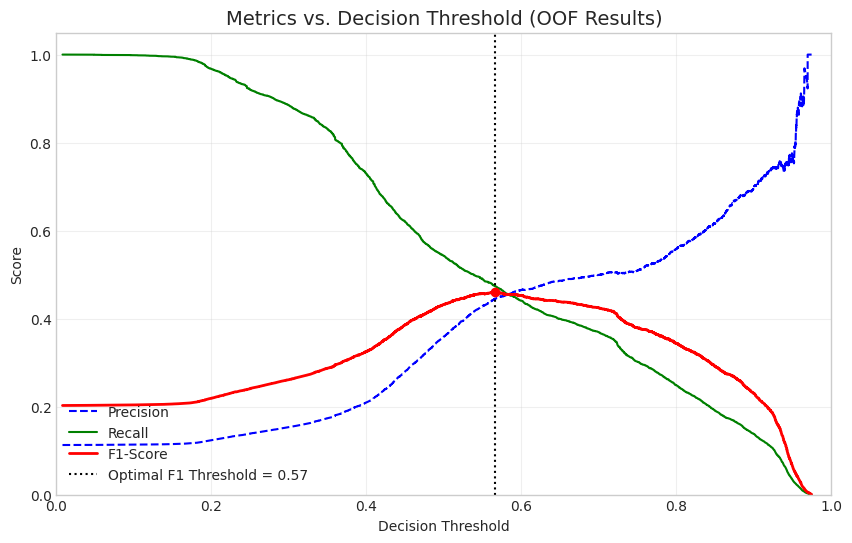

Optimal Threshold for F1-Score: 0.566
✅ 阈值性能曲线已保存至: /kaggle/working/figures/threshold_performance.png


<Figure size 640x480 with 0 Axes>

📊 F1 指数最高的最佳阈值为: 0.566


In [12]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. Calculate metrics over different thresholds using OOF predictions
precision, recall, thresholds = precision_recall_curve(y, oof_preds)

# 2. Calculate F1-Score
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)

# 3. Find optimal threshold for F1-Score
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx]

# 4. Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], 'b--', label='Precision')
plt.plot(thresholds, recall[:-1], 'g-', label='Recall')
plt.plot(thresholds, f1_scores, 'r-', linewidth=2, label='F1-Score')

# Mark the best threshold
plt.axvline(x=best_f1_threshold, color='k', linestyle=':', 
            label=f'Optimal F1 Threshold = {best_f1_threshold:.2f}')
plt.plot(best_f1_threshold, f1_scores[best_f1_idx], 'ro')

plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Metrics vs. Decision Threshold (OOF Results)', fontsize=14)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.show()

print(f"Optimal Threshold for F1-Score: {best_f1_threshold:.3f}")

# 保存图像
threshold_file = os.path.join(SAVE_DIR, 'threshold_performance.png')
plt.savefig(threshold_file, dpi=150, bbox_inches='tight')
print(f"✅ 阈值性能曲线已保存至: {threshold_file}")
plt.show()

print(f"📊 F1 指数最高的最佳阈值为: {best_f1_threshold:.3f}")